In [1]:
import geobr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from pathlib import Path

caminho = Path(r"C:\Users\Felipe\Documents\Python\Clusterizacao_Municipios\dados")
imagens = Path(r"C:\Users\Felipe\Documents\Python\Clusterizacao_Municipios\imagens")

dados_final = pd.read_csv(caminho / 'processados' / 'dados_final.csv')

display(dados_final.head(10))

,cod_municipio,municipio,total_domicilios,perc_agua_rede,perc_esgoto_rede,perc_lixo_coletado,perc_alfabetizacao,renda_media,per_domicilio_urbano,IDHM,IDHM Renda,IDHM Educação,IDHM Longevidade
0,1100015,Alta Floresta D'Oeste - RO,7695,26.484730,0.467836,61.481481,91.59,1210.60,60.347074,0.641,0.657,0.526,0.763
1,1100023,Ariquemes - RO,34768,54.337322,1.993212,90.416475,94.08,1458.57,86.697717,0.702,0.716,0.600,0.806
2,1100031,Cabixi - RO,1967,39.298424,1.576004,61.057448,89.82,1323.79,53.186320,0.650,0.650,0.559,0.757
3,1100049,Cacoal - RO,31917,80.067049,67.189899,85.656547,93.71,1625.88,82.759216,0.718,0.727,0.620,0.821
4,1100056,Cerejeiras - RO,5873,49.480674,57.994211,87.042397,92.15,1554.33,88.835746,0.692,0.688,0.602,0.799
5,1100064,Colorado do Oeste - RO,5991,70.806209,2.620598,77.249207,90.47,1666.54,74.755794,0.685,0.676,0.584,0.814
6,1100072,Corumbiara - RO,2840,20.985915,0.704225,47.887324,91.52,1234.62,36.973002,0.613,0.630,0.473,0.774
7,1100080,Costa Marques - RO,4161,19.346311,0.048065,63.566450,92.92,1088.06,52.823315,0.611,0.616,0.493,0.751
8,1100098,Espigão D'Oeste - RO,10470,44.871060,6.599809,74.288443,92.01,1371.66,72.931257,0.672,0.691,0.536,0.819
9,1100106,Guajará-Mirim - RO,11803,40.464289,9.014657,78.141151,94.16,1035.94,80.577348,0.657,0.663,0.519,0.823


In [2]:
display(dados_final.info())
display(dados_final.describe())

print(dados_final.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5565 entries, 0 to 5564
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cod_municipio         5565 non-null   int64  
 1   municipio             5565 non-null   object 
 2   total_domicilios      5565 non-null   int64  
 3   perc_agua_rede        5557 non-null   float64
 4   perc_esgoto_rede      5540 non-null   float64
 5   perc_lixo_coletado    5565 non-null   float64
 6   perc_alfabetizacao    5565 non-null   float64
 7   renda_media           5565 non-null   float64
 8   per_domicilio_urbano  5565 non-null   float64
 9   IDHM                  5565 non-null   float64
 10  IDHM Renda            5565 non-null   float64
 11  IDHM Educação         5565 non-null   float64
 12  IDHM Longevidade      5565 non-null   float64
dtypes: float64(10), int64(2), object(1)
memory usage: 565.3+ KB


None

,cod_municipio,total_domicilios,perc_agua_rede,perc_esgoto_rede,perc_lixo_coletado,perc_alfabetizacao,renda_media,per_domicilio_urbano,IDHM,IDHM Renda,IDHM Educação,IDHM Longevidade
count,5.565000e+03,5.565000e+03,5557.000000,5540.000000,5565.000000,5565.000000,5565.000000,5565.000000,5565.000000,5565.000000,5565.000000,5565.000000
mean,3.253053e+06,1.301642e+04,71.838354,37.915331,80.237404,88.194753,1211.229013,69.046887,0.659157,0.642873,0.559094,0.801564
std,9.845215e+05,7.757255e+04,19.418299,32.981274,17.421065,7.561306,493.113855,20.129409,0.071997,0.080662,0.093328,0.044681
min,1.100015e+06,3.220000e+02,0.248051,0.031476,1.683609,63.190000,288.650000,7.330868,0.418000,0.400000,0.207000,0.672000
25%,2.512101e+06,1.876000e+03,60.718454,4.137819,69.334248,82.030000,772.340000,54.115407,0.599000,0.572000,0.490000,0.769000
50%,3.146206e+06,3.885000e+03,75.835592,32.614653,85.067064,90.620000,1182.360000,70.835068,0.665000,0.654000,0.560000,0.808000
75%,4.119004e+06,8.377000e+03,86.995005,67.880505,94.810847,94.430000,1520.130000,86.054422,0.718000,0.707000,0.631000,0.836000
max,5.300108e+06,4.307665e+06,100.000000,99.948383,100.000000,99.100000,4299.910000,100.000000,0.862000,0.891000,0.825000,0.894000


cod_municipio            0
municipio                0
total_domicilios         0
perc_agua_rede           8
perc_esgoto_rede        25
perc_lixo_coletado       0
perc_alfabetizacao       0
renda_media              0
per_domicilio_urbano     0
IDHM                     0
IDHM Renda               0
IDHM Educação            0
IDHM Longevidade         0
dtype: int64


In [3]:
dados_final.insert(2, 'uf', dados_final['municipio'].str[-2:])

display(dados_final.head())

,cod_municipio,municipio,uf,total_domicilios,perc_agua_rede,perc_esgoto_rede,perc_lixo_coletado,perc_alfabetizacao,renda_media,per_domicilio_urbano,IDHM,IDHM Renda,IDHM Educação,IDHM Longevidade
0,1100015,Alta Floresta D'Oeste - RO,RO,7695,26.484730,0.467836,61.481481,91.59,1210.60,60.347074,0.641,0.657,0.526,0.763
1,1100023,Ariquemes - RO,RO,34768,54.337322,1.993212,90.416475,94.08,1458.57,86.697717,0.702,0.716,0.600,0.806
2,1100031,Cabixi - RO,RO,1967,39.298424,1.576004,61.057448,89.82,1323.79,53.186320,0.650,0.650,0.559,0.757
3,1100049,Cacoal - RO,RO,31917,80.067049,67.189899,85.656547,93.71,1625.88,82.759216,0.718,0.727,0.620,0.821
4,1100056,Cerejeiras - RO,RO,5873,49.480674,57.994211,87.042397,92.15,1554.33,88.835746,0.692,0.688,0.602,0.799


In [4]:
dados_final['perc_agua_rede'] = dados_final.groupby('uf')['perc_agua_rede'].transform(lambda x: x.fillna(x.median()))
dados_final['perc_esgoto_rede'] = dados_final.groupby('uf')['perc_esgoto_rede'].transform(lambda x: x.fillna(x.median()))

display(dados_final.sample(5))
display(dados_final.describe())

print(dados_final.isna().sum())

,cod_municipio,municipio,uf,total_domicilios,perc_agua_rede,perc_esgoto_rede,perc_lixo_coletado,perc_alfabetizacao,renda_media,per_domicilio_urbano,IDHM,IDHM Renda,IDHM Educação,IDHM Longevidade
3531,3523206,Itararé - SP,SP,16525,94.432678,88.980333,97.531014,95.61,1297.43,94.504703,0.703,0.668,0.649,0.803
3597,3529500,Mendonça - SP,SP,2315,87.775378,93.822894,96.803456,94.81,1756.32,88.861828,0.744,0.720,0.663,0.863
1670,2702108,Colônia Leopoldina - AL,AL,5176,68.991499,78.458269,86.340804,74.12,704.10,83.257461,0.517,0.548,0.363,0.693
3021,3166204,Senhora dos Remédios - MG,MG,3720,79.086022,52.849462,74.462366,91.90,990.54,51.781587,0.626,0.578,0.548,0.776
4755,4307401,Esmeralda - RS,RS,1248,69.551282,33.974359,87.660256,94.04,1412.83,65.289515,0.680,0.669,0.569,0.827


,cod_municipio,total_domicilios,perc_agua_rede,perc_esgoto_rede,perc_lixo_coletado,perc_alfabetizacao,renda_media,per_domicilio_urbano,IDHM,IDHM Renda,IDHM Educação,IDHM Longevidade
count,5.565000e+03,5.565000e+03,5565.000000,5565.000000,5565.000000,5565.000000,5565.000000,5565.000000,5565.000000,5565.000000,5565.000000,5565.000000
mean,3.253053e+06,1.301642e+04,71.821024,37.776251,80.237404,88.194753,1211.229013,69.046887,0.659157,0.642873,0.559094,0.801564
std,9.845215e+05,7.757255e+04,19.414621,32.978762,17.421065,7.561306,493.113855,20.129409,0.071997,0.080662,0.093328,0.044681
min,1.100015e+06,3.220000e+02,0.248051,0.031476,1.683609,63.190000,288.650000,7.330868,0.418000,0.400000,0.207000,0.672000
25%,2.512101e+06,1.876000e+03,60.734370,4.059493,69.334248,82.030000,772.340000,54.115407,0.599000,0.572000,0.490000,0.769000
50%,3.146206e+06,3.885000e+03,75.791805,32.325269,85.067064,90.620000,1182.360000,70.835068,0.665000,0.654000,0.560000,0.808000
75%,4.119004e+06,8.377000e+03,86.956522,67.686480,94.810847,94.430000,1520.130000,86.054422,0.718000,0.707000,0.631000,0.836000
max,5.300108e+06,4.307665e+06,100.000000,99.948383,100.000000,99.100000,4299.910000,100.000000,0.862000,0.891000,0.825000,0.894000


cod_municipio           0
municipio               0
uf                      0
total_domicilios        0
perc_agua_rede          0
perc_esgoto_rede        0
perc_lixo_coletado      0
perc_alfabetizacao      0
renda_media             0
per_domicilio_urbano    0
IDHM                    0
IDHM Renda              0
IDHM Educação           0
IDHM Longevidade        0
dtype: int64


In [5]:
colunas_clustering = ['perc_agua_rede', 'perc_esgoto_rede', 'perc_lixo_coletado', 
                      'perc_alfabetizacao', 'renda_media', 'per_domicilio_urbano',
                      'IDHM', 'IDHM Renda', 'IDHM Educação', 'IDHM Longevidade']

X = dados_final[colunas_clustering]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

display(X_scaled)

array([[-2.33537227e+00, -1.13138773e+00, -1.07671993e+00, ...,
         1.75153000e-01, -3.54631450e-01, -8.63185844e-01],
       [-9.00623982e-01, -1.08513030e+00,  5.84349188e-01, ...,
         9.06668980e-01,  4.38344405e-01,  9.92813946e-02],
       [-1.67531071e+00, -1.09778224e+00, -1.10106240e+00, ...,
         8.83629686e-02, -1.00708184e-03, -9.97483598e-01],
       ...,
       [ 1.25853517e-01, -9.89901124e-01,  1.48258104e-01, ...,
        -2.95992885e-01, -2.68904330e-01,  3.67876903e-01],
       [-1.15476725e+00, -1.12053578e+00, -9.90599784e-01, ...,
        -1.72007126e-01, -5.79665138e-01,  9.74955844e-03],
       [ 1.10992606e+00,  1.46899526e+00,  1.07194964e+00, ...,
         2.72925964e+00,  1.96000078e+00,  1.59893965e+00]],
      shape=(5565, 10))

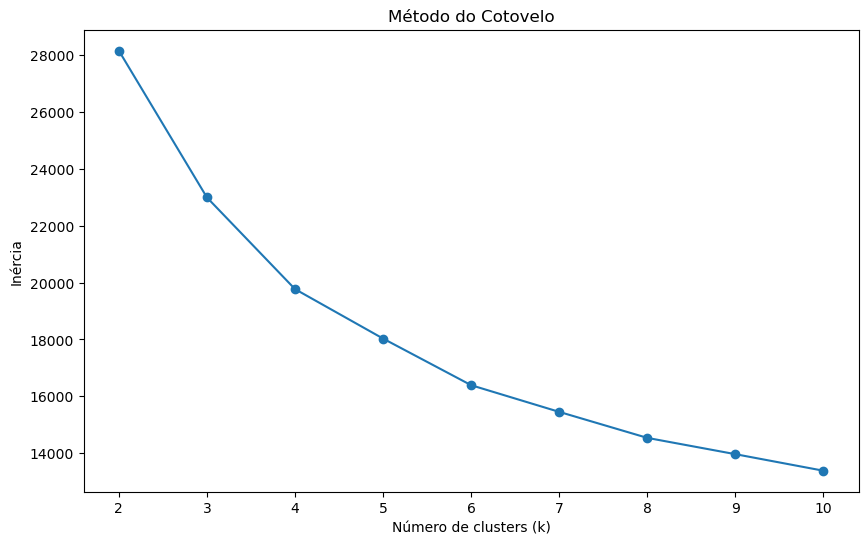

In [6]:
inercia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inercia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inercia, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inércia')
plt.title('Método do Cotovelo')

plt.savefig(imagens / "cotovelo.png", dpi=150, bbox_inches='tight')

plt.show()

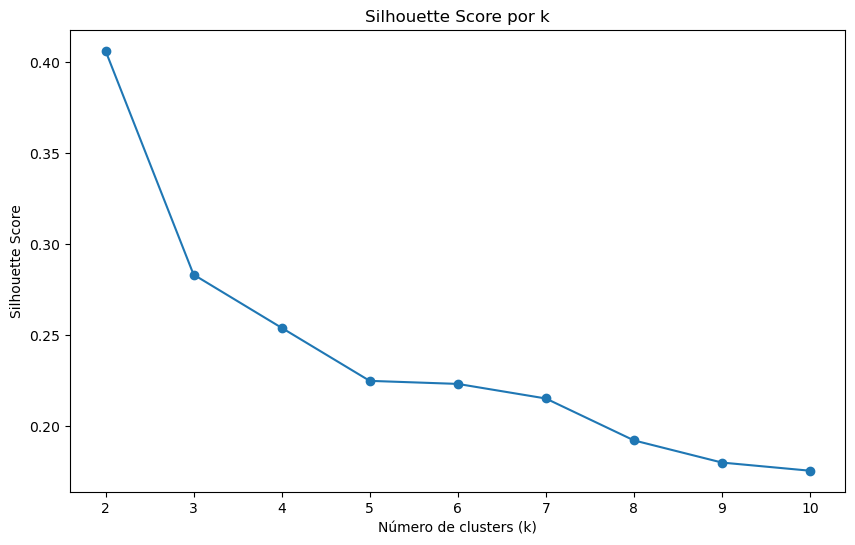

In [7]:
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score por k')

plt.savefig(imagens / "silhouette.png", dpi=150, bbox_inches='tight')

plt.show()

In [8]:
kmeans = KMeans(n_clusters=5, random_state=42)
dados_final['cluster'] = kmeans.fit_predict(X_scaled)

print(dados_final['cluster'].value_counts())

cluster
1    1425
2    1242
4    1195
0     884
3     819
Name: count, dtype: int64


In [9]:
perfil = dados_final.groupby('cluster')[colunas_clustering].mean().round(2)
display(perfil)

,perc_agua_rede,perc_esgoto_rede,perc_lixo_coletado,perc_alfabetizacao,renda_media,per_domicilio_urbano,IDHM,IDHM Renda,IDHM Educação,IDHM Longevidade
cluster,,,,,,,,,,
0,47.42,11.26,51.71,79.59,712.61,44.39,0.56,0.54,0.44,0.76
1,88.34,74.69,96.07,95.20,1648.95,89.75,0.74,0.73,0.66,0.84
2,73.01,25.45,76.30,80.69,767.88,65.49,0.60,0.57,0.49,0.76
3,63.24,14.45,80.10,93.69,1704.19,53.28,0.70,0.70,0.59,0.83
4,74.82,42.17,86.65,90.25,1181.05,77.10,0.67,0.65,0.57,0.81


In [10]:
nomes_clusters = {
    0: 'Crítico',
    1: 'Desenvolvido',
    2: 'Em Desenvolvimento',
    3: 'Rural de Média Renda',
    4: 'Em Transição'
}

dados_final['cluster_nome'] = dados_final['cluster'].map(nomes_clusters)

print(dados_final['cluster_nome'].value_counts())

cluster_nome
Desenvolvido            1425
Em Desenvolvimento      1242
Em Transição            1195
Crítico                  884
Rural de Média Renda     819
Name: count, dtype: int64


In [11]:
mapa = geobr.read_municipality(code_muni="all", year=2020)
display(mapa.head())
display(mapa.shape)

,code_muni,name_muni,code_state,abbrev_state,name_state,code_region,name_region,geometry
0,1100015.0,Alta Floresta D'oeste,11.0,RO,Rondônia,1.0,Norte,"MULTIPOLYGON (((-62.19465 -11.82746, -62.18945..."
1,1100023.0,Ariquemes,11.0,RO,Rondônia,1.0,Norte,"MULTIPOLYGON (((-62.53648 -9.73222, -62.52765 ..."
2,1100031.0,Cabixi,11.0,RO,Rondônia,1.0,Norte,"MULTIPOLYGON (((-60.37119 -13.36655, -60.37661..."
3,1100049.0,Cacoal,11.0,RO,Rondônia,1.0,Norte,"MULTIPOLYGON (((-61.0008 -11.29737, -61.00103 ..."
4,1100056.0,Cerejeiras,11.0,RO,Rondônia,1.0,Norte,"MULTIPOLYGON (((-61.49976 -13.00525, -61.49426..."


(5570, 8)

In [12]:
mapa['code_muni'] = mapa['code_muni'].astype(int)
display(mapa.head())

,code_muni,name_muni,code_state,abbrev_state,name_state,code_region,name_region,geometry
0,1100015,Alta Floresta D'oeste,11.0,RO,Rondônia,1.0,Norte,"MULTIPOLYGON (((-62.19465 -11.82746, -62.18945..."
1,1100023,Ariquemes,11.0,RO,Rondônia,1.0,Norte,"MULTIPOLYGON (((-62.53648 -9.73222, -62.52765 ..."
2,1100031,Cabixi,11.0,RO,Rondônia,1.0,Norte,"MULTIPOLYGON (((-60.37119 -13.36655, -60.37661..."
3,1100049,Cacoal,11.0,RO,Rondônia,1.0,Norte,"MULTIPOLYGON (((-61.0008 -11.29737, -61.00103 ..."
4,1100056,Cerejeiras,11.0,RO,Rondônia,1.0,Norte,"MULTIPOLYGON (((-61.49976 -13.00525, -61.49426..."


In [13]:
mapa_final = mapa.merge(dados_final[['cod_municipio', 'cluster_nome']], 
                        left_on='code_muni', 
                        right_on='cod_municipio', 
                        how='left')

print(mapa_final.shape)
print(mapa_final['cluster_nome'].isna().sum())

(5570, 10)
5


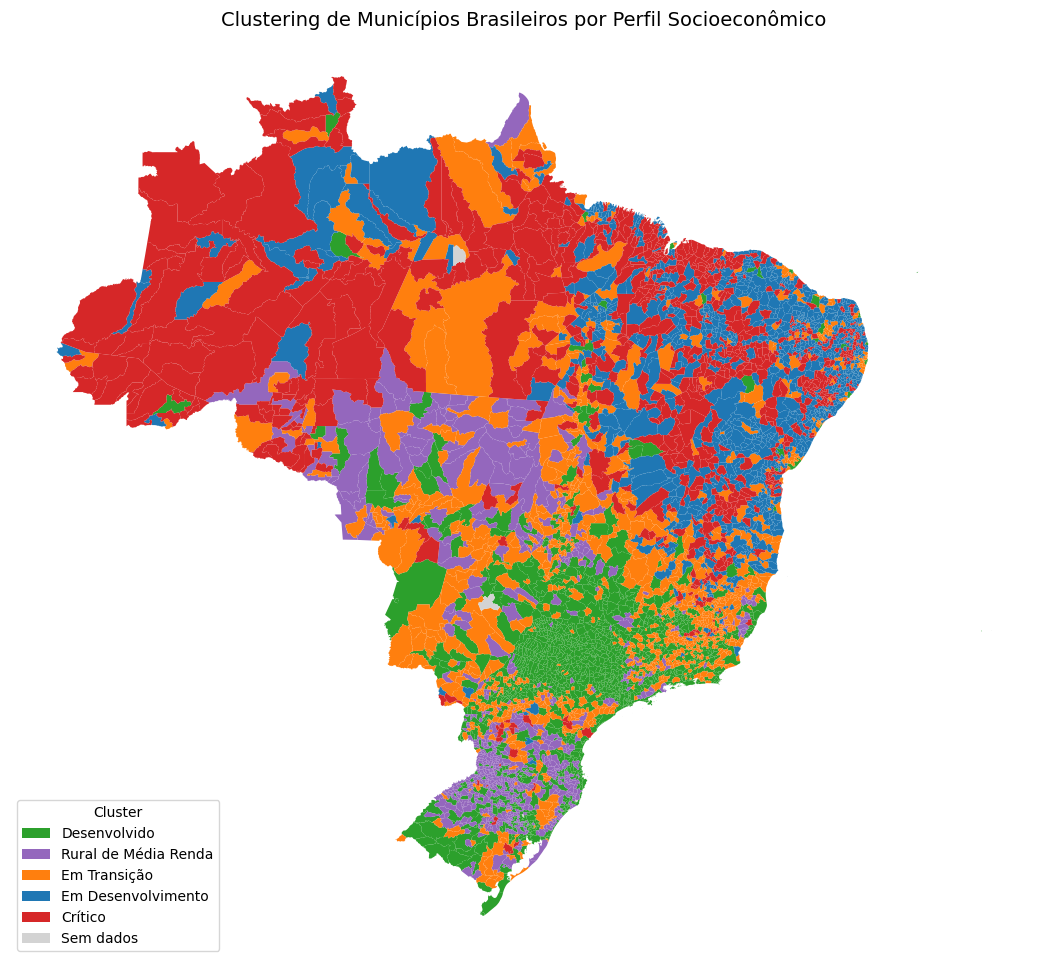

In [14]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(15, 12))

cores = {
    'Desenvolvido': '#2ca02c',
    'Rural de Média Renda': '#9467bd',
    'Em Transição': '#ff7f0e',
    'Em Desenvolvimento': '#1f77b4',
    'Crítico': '#d62728',
}

for cluster, cor in cores.items():
    mapa_final[mapa_final['cluster_nome'] == cluster].plot(ax=ax, color=cor)

mapa_final[mapa_final['cluster_nome'].isna()].plot(ax=ax, color='lightgrey')

legend_elements = [Patch(facecolor=cor, label=cluster) for cluster, cor in cores.items()]
legend_elements.append(Patch(facecolor='lightgrey', label='Sem dados'))

ax.legend(handles=legend_elements, title='Cluster', loc='lower left')
ax.set_title('Clustering de Municípios Brasileiros por Perfil Socioeconômico', fontsize=14)
ax.axis('off')

plt.savefig(imagens / "mapa_clusters.png", dpi=150, bbox_inches='tight')

plt.show()

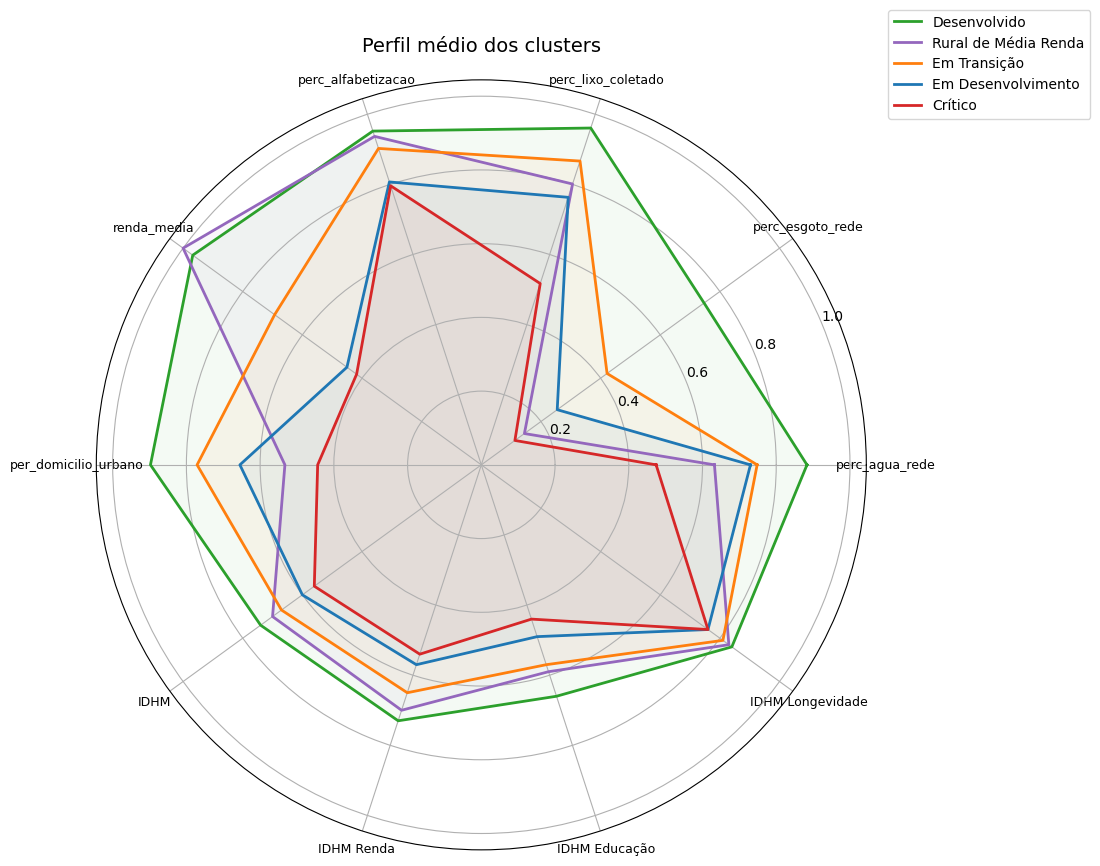

In [15]:
# Cria perfil_radar com escala padronizada entre 0 e 1
perfil_radar = perfil.copy()

colunas_perc = ['perc_agua_rede', 'perc_esgoto_rede', 'perc_lixo_coletado', 
                'perc_alfabetizacao', 'per_domicilio_urbano']
perfil_radar[colunas_perc] = perfil_radar[colunas_perc] / 100
perfil_radar['renda_media'] = perfil_radar['renda_media'] / perfil_radar['renda_media'].max()

# Plota o radar
categorias = colunas_clustering
N = len(categorias)

angulos = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angulos += angulos[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

ordem_plot = ['Desenvolvido', 'Rural de Média Renda', 'Em Transição', 'Em Desenvolvimento', 'Crítico']

for cluster in ordem_plot:
    cor = cores[cluster]
    idx = list(nomes_clusters.values()).index(cluster)
    valores = perfil_radar.loc[perfil_radar.index[idx]].tolist()
    valores += valores[:1]
    ax.plot(angulos, valores, color=cor, linewidth=2, label=cluster)
    ax.fill(angulos, valores, color=cor, alpha=0.05)

ax.set_xticks(angulos[:-1])
ax.set_xticklabels(categorias, size=9)
ax.set_title('Perfil médio dos clusters', size=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.savefig(imagens / "radar_clusters.png", dpi=150, bbox_inches='tight')

plt.show()

In [16]:
tabela_resumo = perfil.copy()
tabela_resumo.index = [nomes_clusters[i] for i in tabela_resumo.index]
tabela_resumo.index.name = 'Cluster'

ordem = ['Desenvolvido', 'Rural de Média Renda', 'Em Transição', 'Em Desenvolvimento', 'Crítico']
tabela_resumo = tabela_resumo.reindex(ordem)

display(tabela_resumo)

,perc_agua_rede,perc_esgoto_rede,perc_lixo_coletado,perc_alfabetizacao,renda_media,per_domicilio_urbano,IDHM,IDHM Renda,IDHM Educação,IDHM Longevidade
Cluster,,,,,,,,,,
Desenvolvido,88.34,74.69,96.07,95.20,1648.95,89.75,0.74,0.73,0.66,0.84
Rural de Média Renda,63.24,14.45,80.10,93.69,1704.19,53.28,0.70,0.70,0.59,0.83
Em Transição,74.82,42.17,86.65,90.25,1181.05,77.10,0.67,0.65,0.57,0.81
Em Desenvolvimento,73.01,25.45,76.30,80.69,767.88,65.49,0.60,0.57,0.49,0.76
Crítico,47.42,11.26,51.71,79.59,712.61,44.39,0.56,0.54,0.44,0.76


In [17]:
dados_final.to_csv(caminho / 'processados' / 'dados_final.csv', index=False)